# CMR Encoding-Stage Internal Diagnostics

Summaries of learned association matrices ($M_{FC}$, $M_{CF}$) and
FC-alignment asymmetry ($\Delta_{FC}$) during context updating.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

from cmr.config import (
    N, BASE_PARAMS,
    B_rec_grid, gamma_fc_grid, eta_grid, B_encD_scale_grid,
    n_sims,
)
from cmr.sweep import sweep_one_param
from cmr.utils import _get_sweep_entry
from cmr.diagnostics_recall import fc_alignment_asymmetry_means
from cmr.diagnostics_encoding import (
    sweep_matrix_norms,
    sweep_w_fc_lag_strength_profile,
    sweep_w_fc_forward_backward_lag_asymmetry,
)
from cmr.visualization import (
    make_sweep_colors, _add_colorbar, line_with_colored_points, plot_split_lags,
    plot_matrix_norms_sweep,
    plot_w_fc_lag_strength_profile_sweep,
    plot_w_fc_forward_backward_lag_asymmetry_sweep,
    plot_fc_alignment_asymmetry_sweep,
    plot_fc_alignment_asymmetry_curves,
)

## Run all four sweeps

In [2]:
sweep_B_rec = sweep_one_param(
    param_name="B_rec",
    param_grid=B_rec_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_rec=0.2  done
  B_rec=0.4  done
  B_rec=0.6  done
  B_rec=0.8  done
  B_rec=1  done
  B_rec=1.2  done


In [3]:
sweep_gamma_fc = sweep_one_param(
    param_name="gamma_fc",
    param_grid=gamma_fc_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  gamma_fc=0.2  done
  gamma_fc=0.3  done
  gamma_fc=0.4  done
  gamma_fc=0.5  done
  gamma_fc=0.6  done
  gamma_fc=0.7  done
  gamma_fc=0.8  done


In [4]:
sweep_eta = sweep_one_param(
    param_name="eta",
    param_grid=eta_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  eta=0.1  done
  eta=0.2  done
  eta=0.3  done
  eta=0.4  done
  eta=0.5  done
  eta=0.6  done


In [5]:
sweep_B_enc_scale = sweep_one_param(
    param_name="B_encD_scale",
    param_grid=B_encD_scale_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_encD_scale=0.2  done
  B_encD_scale=0.4  done
  B_encD_scale=0.6  done
  B_encD_scale=0.8  done
  B_encD_scale=1  done


---
## $B_{rec}$

### Neighbor context-to-item-input alignment ($\Delta_{FC}$) asymmetry during updating

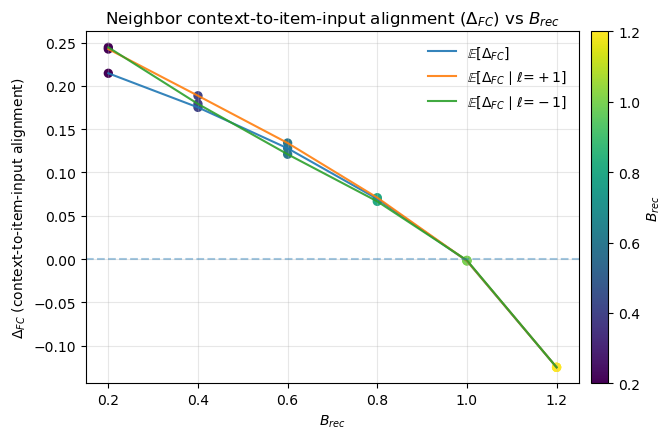

In [6]:
plot_fc_alignment_asymmetry_sweep(sweep_B_rec, B_rec_grid, param_name=r"$B_{rec}$")

---
## $\gamma_{fc}$

### $M_{FC}$ norms

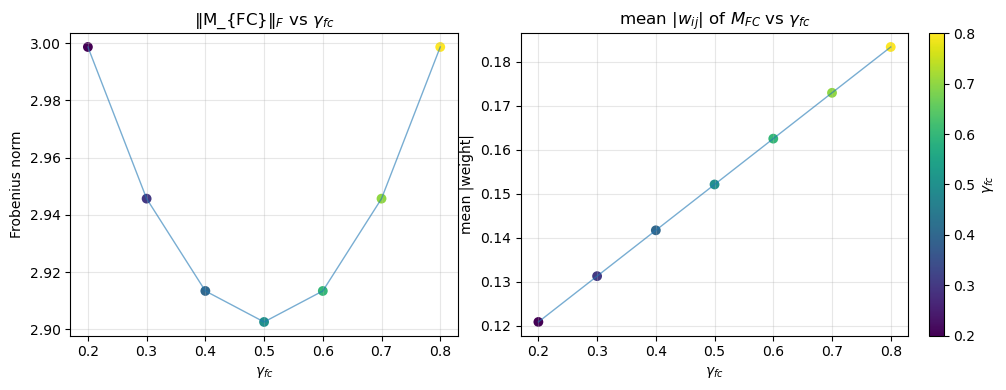

In [7]:
plot_matrix_norms_sweep(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$", matrix_key="net_w_fc")

### $M_{FC}$ lag-strength profile

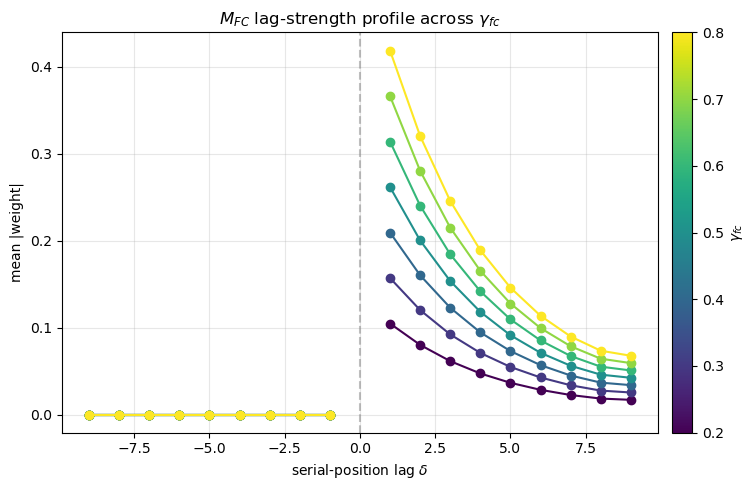

In [8]:
plot_w_fc_lag_strength_profile_sweep(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$", matrix_key="net_w_fc")

### $M_{FC}$ forward/backward lag asymmetry

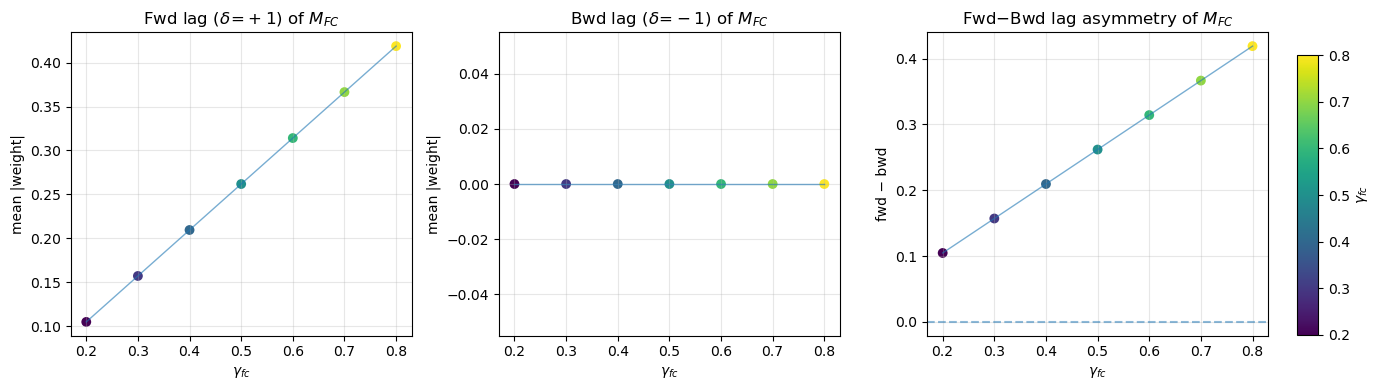

In [9]:
plot_w_fc_forward_backward_lag_asymmetry_sweep(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$", matrix_key="net_w_fc")

### Neighbor context-to-item-input alignment ($\Delta_{FC}$) asymmetry during updating

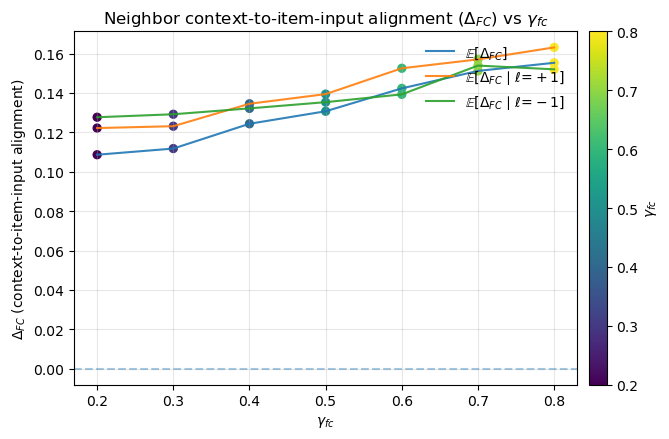

In [10]:
plot_fc_alignment_asymmetry_sweep(sweep_gamma_fc, gamma_fc_grid, param_name=r"$\gamma_{fc}$")

### $\Delta_{FC}$ side-by-side: $\gamma_{fc}$ and $B_{rec}$

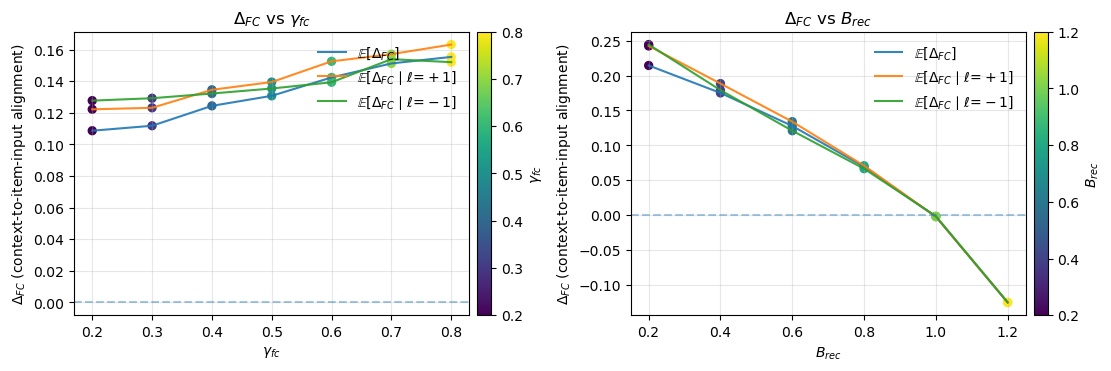

In [11]:
m_all_g, m_fwd_g, m_bwd_g = fc_alignment_asymmetry_means(sweep_gamma_fc, gamma_fc_grid)
m_all_b, m_fwd_b, m_bwd_b = fc_alignment_asymmetry_means(sweep_B_rec, B_rec_grid)

gc, gn, gm = make_sweep_colors(gamma_fc_grid)
bc, bn, bm = make_sweep_colors(B_rec_grid)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
plot_fc_alignment_asymmetry_curves(
    axs[0], gamma_fc_grid, m_all_g, m_fwd_g, m_bwd_g, gc,
    title=r"$\Delta_{FC}$ vs $\gamma_{fc}$", xlabel=r"$\gamma_{fc}$")
plot_fc_alignment_asymmetry_curves(
    axs[1], B_rec_grid, m_all_b, m_fwd_b, m_bwd_b, bc,
    title=r"$\Delta_{FC}$ vs $B_{rec}$", xlabel=r"$B_{rec}$")

sm0 = mpl.cm.ScalarMappable(norm=gn, cmap=gm); sm0.set_array([])
sm1 = mpl.cm.ScalarMappable(norm=bn, cmap=bm); sm1.set_array([])
fig.colorbar(sm0, ax=axs[0], pad=0.02).set_label(r"$\gamma_{fc}$")
fig.colorbar(sm1, ax=axs[1], pad=0.02).set_label(r"$B_{rec}$")
plt.show()

---
## $\eta$

### Neighbor context-to-item-input alignment ($\Delta_{FC}$) asymmetry during updating

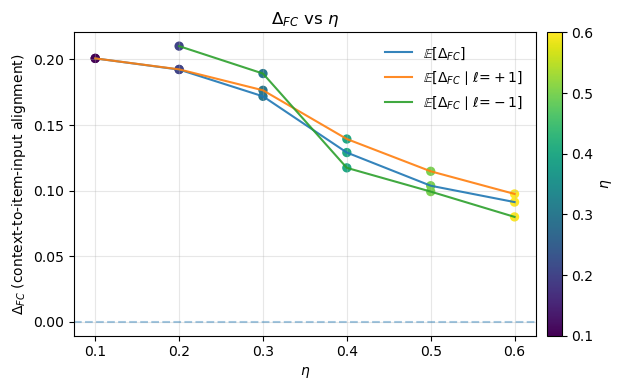

In [12]:
m_all, m_fwd, m_bwd = fc_alignment_asymmetry_means(sweep_eta, eta_grid)
colors, norm_c, cmap_c = make_sweep_colors(eta_grid)

fig, ax = plt.subplots(figsize=(6.5, 4))
plot_fc_alignment_asymmetry_curves(
    ax, eta_grid, m_all, m_fwd, m_bwd, colors,
    title=r"$\Delta_{FC}$ vs $\eta$", xlabel=r"$\eta$")
sm = mpl.cm.ScalarMappable(norm=norm_c, cmap=cmap_c); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02).set_label(r"$\eta$")
fig.tight_layout(); plt.show()

---
## $B_{enc}$ scale

### $M_{FC}$ norms

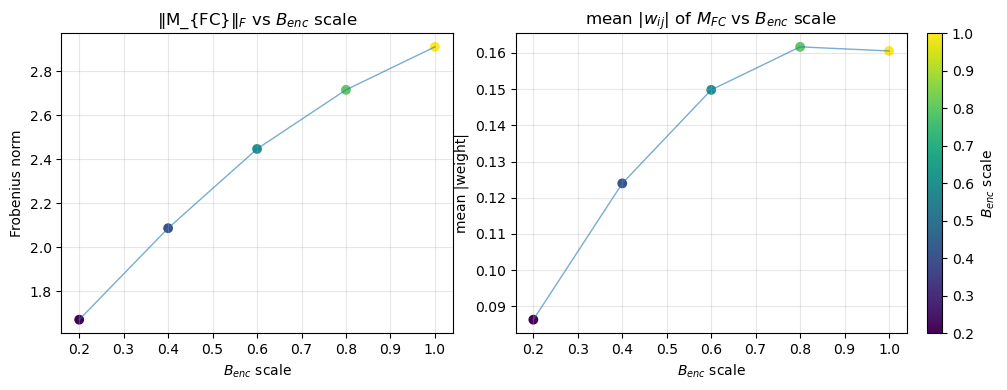

In [13]:
plot_matrix_norms_sweep(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale", matrix_key="net_w_fc")

### $M_{CF}$ norms

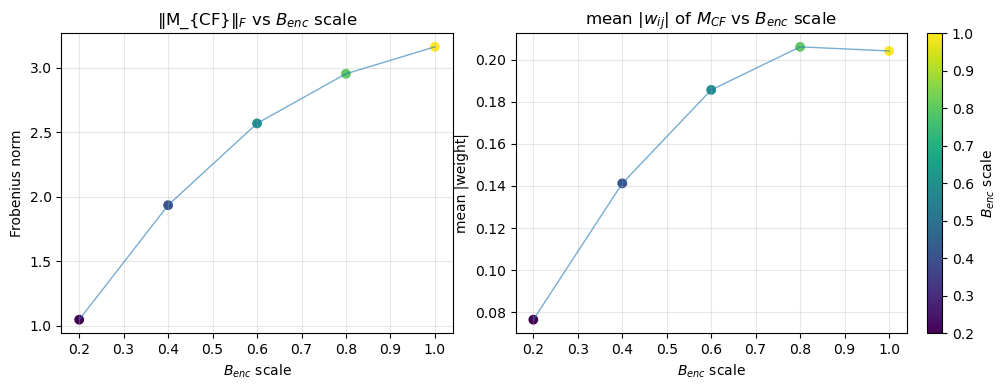

In [14]:
plot_matrix_norms_sweep(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale", matrix_key="net_w_cf")

### $M_{FC}$ lag-strength profile

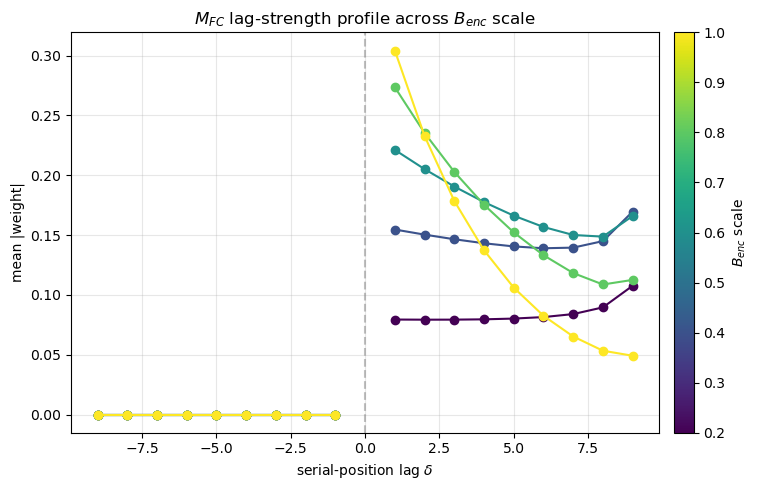

In [15]:
plot_w_fc_lag_strength_profile_sweep(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale", matrix_key="net_w_fc")

### $M_{FC}$ forward/backward lag asymmetry

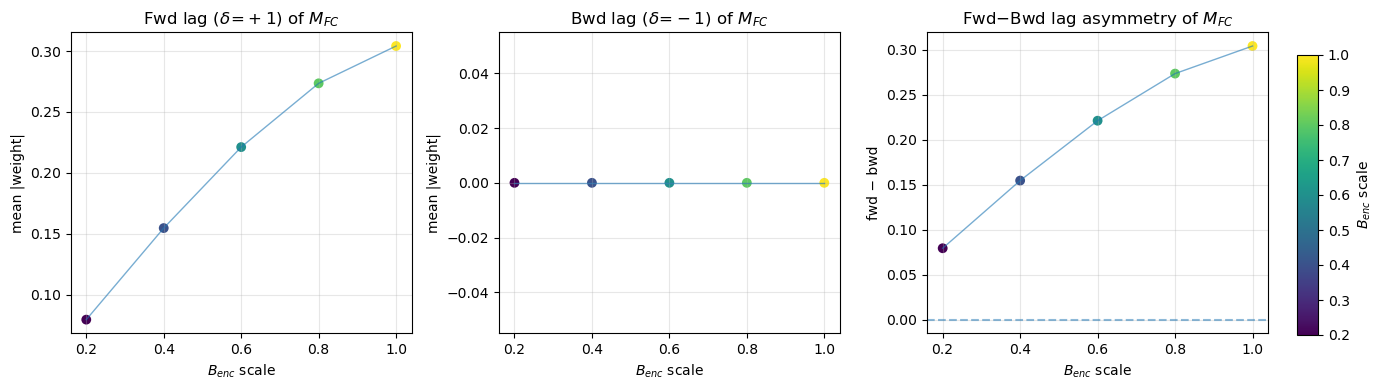

In [16]:
plot_w_fc_forward_backward_lag_asymmetry_sweep(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale", matrix_key="net_w_fc")

### Neighbor context-to-item-input alignment ($\Delta_{FC}$) asymmetry during updating

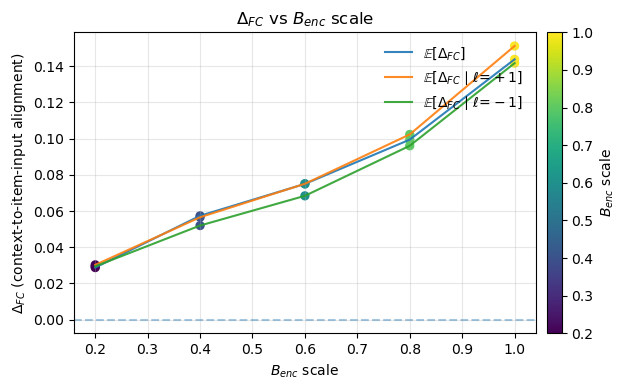

In [17]:
m_all, m_fwd, m_bwd = fc_alignment_asymmetry_means(sweep_B_enc_scale, B_encD_scale_grid)
colors, norm_c, cmap_c = make_sweep_colors(B_encD_scale_grid)

fig, ax = plt.subplots(figsize=(6.5, 4))
plot_fc_alignment_asymmetry_curves(
    ax, B_encD_scale_grid, m_all, m_fwd, m_bwd, colors,
    title=r"$\Delta_{FC}$ vs $B_{enc}$ scale", xlabel=r"$B_{enc}$ scale")
sm = mpl.cm.ScalarMappable(norm=norm_c, cmap=cmap_c); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02).set_label(r"$B_{enc}$ scale")
fig.tight_layout(); plt.show()

---
## Cross-parameter comparison

Four rows: $\|M_{FC}\|_F$, mean $|w_{ij}|$, fwd/bwd lag asymmetry,
$\mathbb{E}[\Delta_{FC}]$.  Four columns: one per swept parameter.

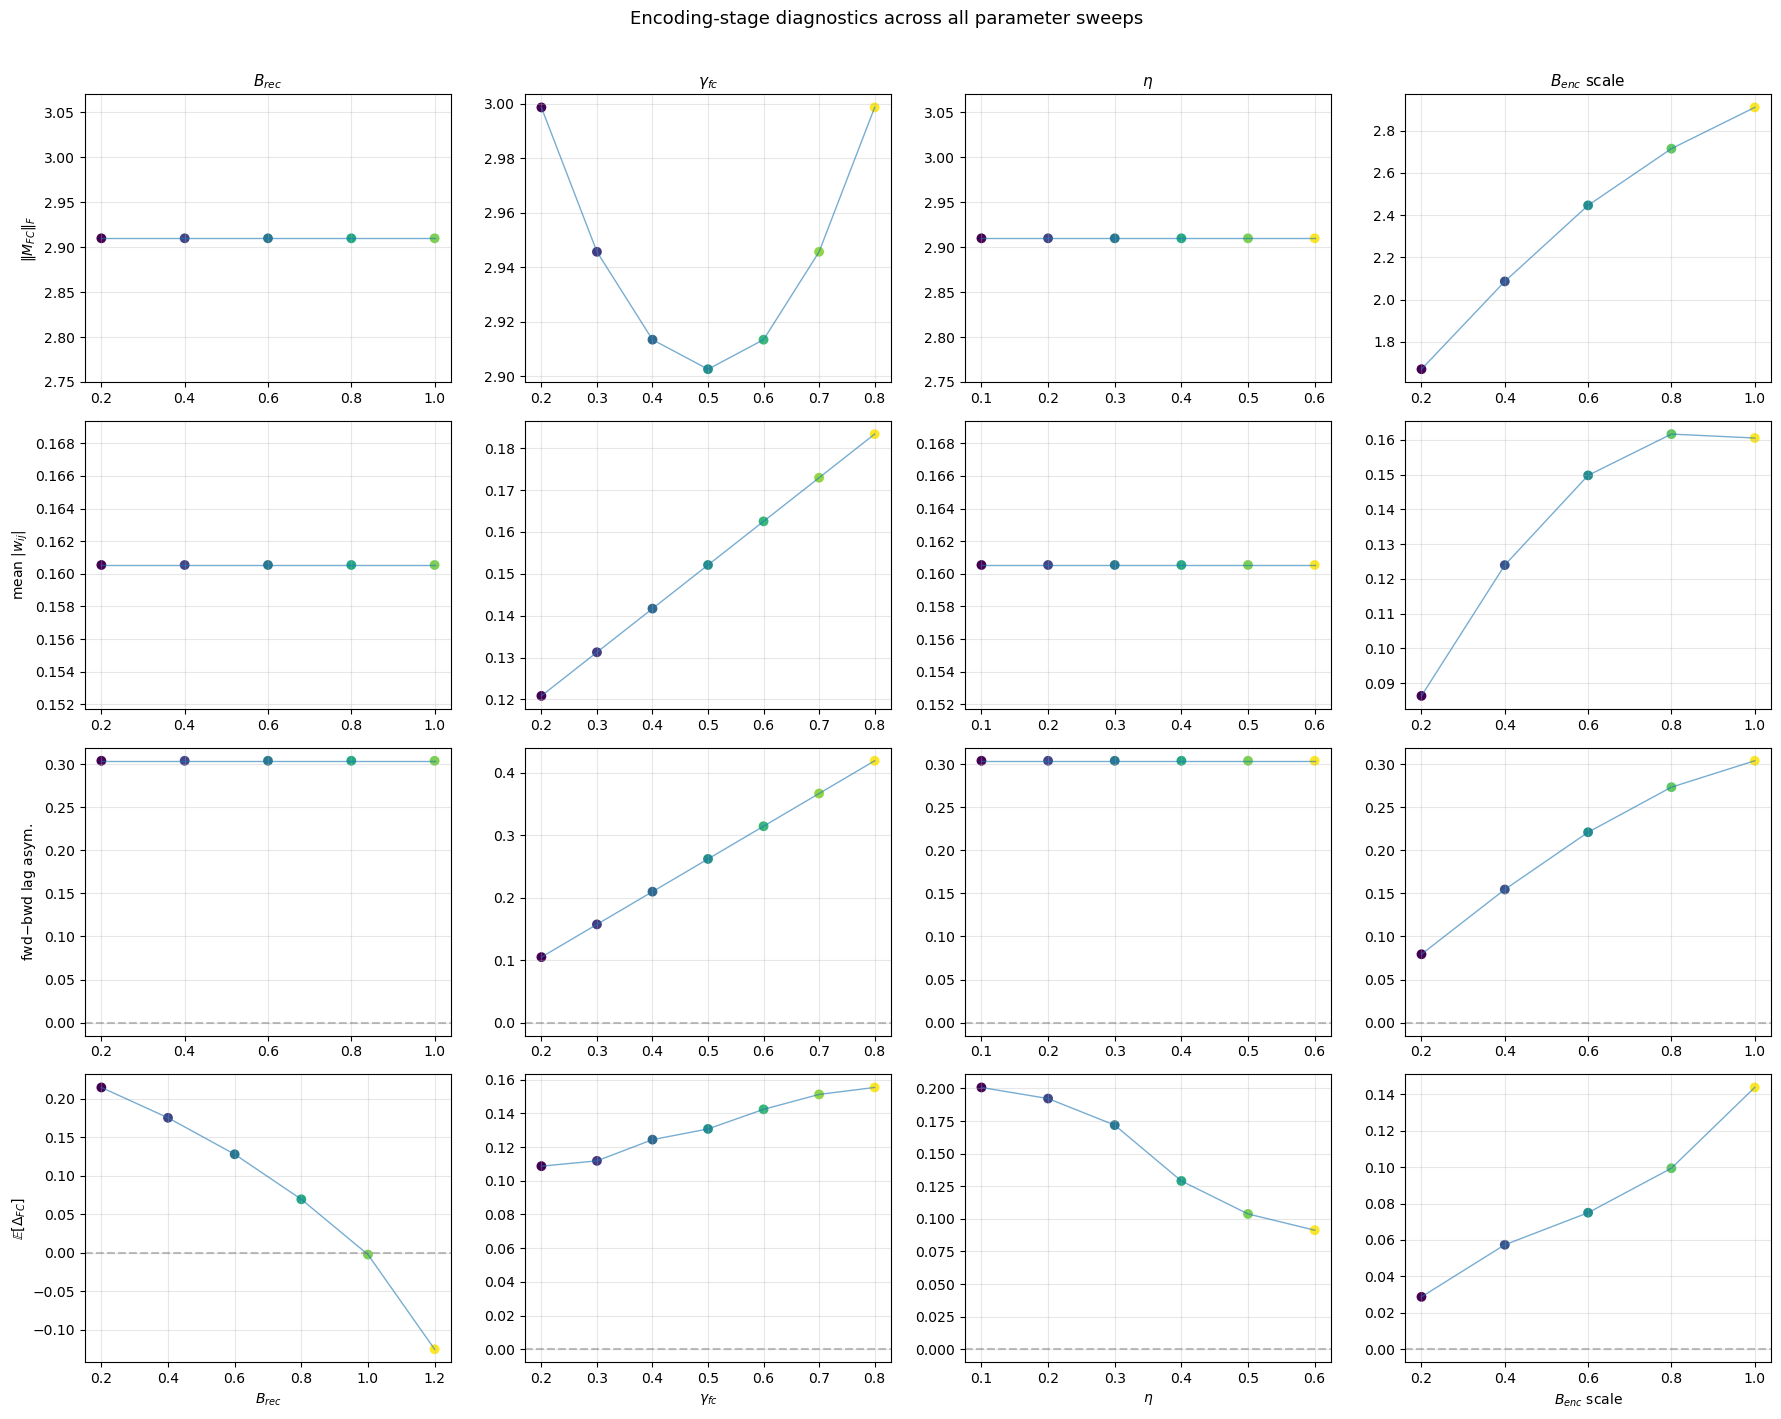

In [18]:
sweeps = [
    (sweep_B_rec,       B_rec_grid,        r"$B_{rec}$"),
    (sweep_gamma_fc,    gamma_fc_grid,      r"$\gamma_{fc}$"),
    (sweep_eta,         eta_grid,           r"$\eta$"),
    (sweep_B_enc_scale, B_encD_scale_grid,  r"$B_{enc}$ scale"),
]

fig, axs = plt.subplots(4, 4, figsize=(18, 14), sharex=False)

for col, (sweep, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid)

    # Row 0: ||M_FC||_F
    frob, mabs = sweep_matrix_norms(sweep, grid, 'net_w_fc')
    ax = axs[0, col]
    line_with_colored_points(ax, grid, frob, colors)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"$\|M_{FC}\|_F$")

    # Row 1: mean |w_ij|
    ax = axs[1, col]
    line_with_colored_points(ax, grid, mabs, colors)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"mean $|w_{ij}|$")

    # Row 2: fwd - bwd lag asymmetry
    fwd, bwd, asym = sweep_w_fc_forward_backward_lag_asymmetry(sweep, grid)
    ax = axs[2, col]
    line_with_colored_points(ax, grid, asym, colors)
    ax.axhline(0, ls="--", color="gray", alpha=0.5)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"fwd$-$bwd lag asym.")

    # Row 3: E[Δ_FC]
    m_all, m_fwd, m_bwd = fc_alignment_asymmetry_means(sweep, grid)
    ax = axs[3, col]
    line_with_colored_points(ax, grid, m_all, colors)
    ax.axhline(0, ls="--", color="gray", alpha=0.5)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"$\mathbb{E}[\Delta_{FC}]$")
    ax.set_xlabel(label)

    # Column title
    axs[0, col].set_title(label, fontsize=11)

fig.suptitle("Encoding-stage diagnostics across all parameter sweeps", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()